## 1. Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Cleaned Dataset

The cleaned dataset generated during task 1 will be used as the basis for the exploratory data analysis.

In [5]:
import os
os.getcwd()

'C:\\Users\\HP'

In [8]:
df = pd.read_csv("cleaned_sentiment_dataset.csv")

## Dataset Overview

1. 710 rows
2. 13 columns
3. 0 missing values
4. 0 duplicate records

In [9]:
df.shape

(710, 13)

## Descriptive Statistics

In [10]:
df.describe()

,Retweets,Likes,Year,Month,Day,Hour
count,710.000000,710.000000,710.000000,710.000000,710.000000,710.000000
mean,21.549296,42.981690,2020.481690,6.094366,15.494366,15.600000
std,7.117567,14.202682,2.827246,3.400962,8.439236,4.064779
min,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,18.000000,35.000000,2019.000000,3.000000,10.000000,13.000000
50%,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


## Visualizations

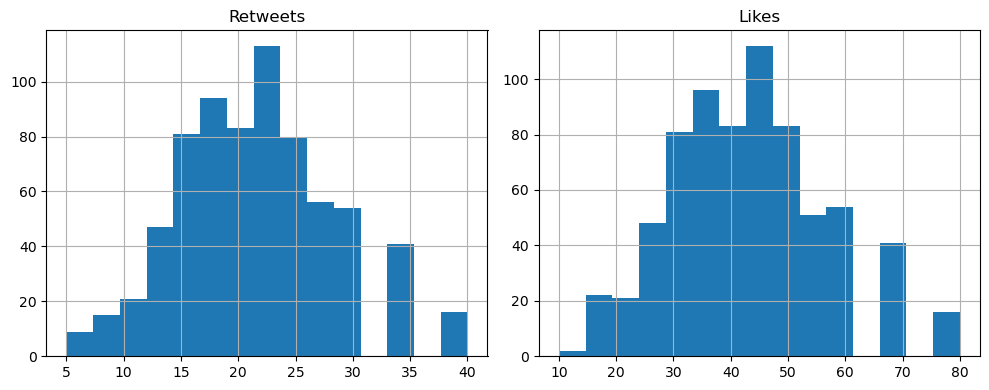

In [11]:
import matplotlib.pyplot as plt

df[['Retweets', 'Likes']].hist(bins=15, figsize=(10, 4))

plt.tight_layout()
plt.show()

In [12]:
df[['Retweets', 'Likes']].corr()

,Retweets,Likes
Retweets,1.00000,0.99847
Likes,0.99847,1.00000


In [14]:
df.plot.scatter(x='Likes', y='Retweets', figsize(8, 5))

plt.title('Likes vs Retweets')
plt.xlabel('Likes')
plt.ylabel('Retweets')
plt.show()

SyntaxError: positional argument follows keyword argument (2951921093.py, line 1)

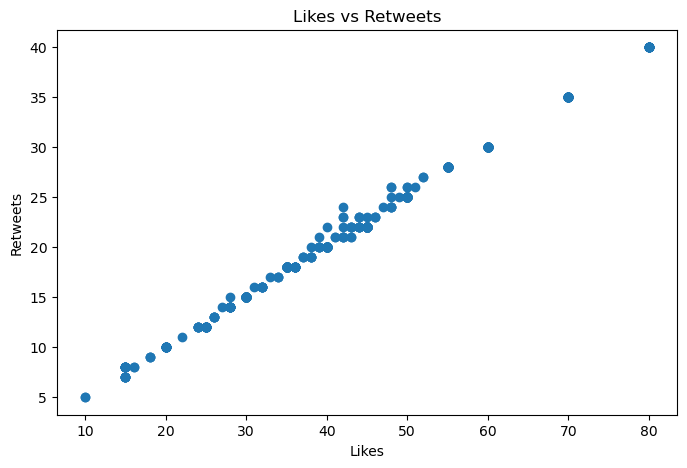

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Likes'], df['Retweets'])

plt.title('Likes vs Retweets')
plt.xlabel('Likes')
plt.ylabel('Retweets')

plt.show()

In [16]:
df['Sentiment'].value_counts()

Sentiment
Positive       45
Joy            44
Excitement     37
Neutral        18
Contentment    18
               ..
Suffering       1
Marvel          1
Spark           1
Immersion       1
Intrigue        1
Name: count, Length: 191, dtype: int64

In [20]:
print(type(df['Likes']))
print(df['Likes'].head())
           

<class 'pandas.core.series.Series'>
0    30
1    10
2    40
3    15
4    25
Name: Likes, dtype: int64


In [23]:
print(type(df))
print(type(df.groupby))
print(type(df.groupby('Sentiment')))

<class 'pandas.core.frame.DataFrame'>
<class 'method'>
<class 'pandas.core.groupby.generic.DataFrameGroupBy'>


## Sentiment vs Engagement

In [24]:
df.groupby('Sentiment').Likes.apply(lambda x: sum(x)/len(x)).sort_values(ascending=False)

Sentiment
Motivation      80.000000
Mesmerizing     80.000000
Wonder          73.333333
Energy          70.000000
Mindfulness     70.000000
                  ...    
Boredom         20.000000
Numbness        18.400000
Jealousy        18.333333
Resentment      18.333333
Helplessness    15.000000
Name: Likes, Length: 191, dtype: float64

In [25]:
df.groupby('Sentiment').Retweets.apply(lambda x: sum(x)/len(x)).sort_values(ascending=False)

Sentiment
Mesmerizing             40.000000
Motivation              40.000000
Wonder                  36.666667
Whispers of the Past    35.000000
Suspense                35.000000
                          ...    
Boredom                 10.000000
Numbness                 9.400000
Jealousy                 9.333333
Resentment               9.000000
Helplessness             8.000000
Name: Retweets, Length: 191, dtype: float64

## Temporal Analysis

In [26]:
df.groupby('Hour').Likes.apply(lambda x: sum(x)/len(x)).sort_values(ascending=False)

Hour
23    56.571429
5     55.000000
22    50.515152
20    50.183673
13    45.758621
18    44.825397
19    44.770270
21    44.250000
7     43.166667
17    42.195652
10    41.827586
14    41.717391
12    41.000000
15    40.688889
8     40.476190
16    39.173913
11    37.342857
6     37.000000
9     36.777778
2     36.000000
3     36.000000
0     35.000000
Name: Likes, dtype: float64

## Final EDA Findings

1. The dataset contains 710 observations and 13 variables and contains no missing values or duplicate records.
2. Retweets range from 5 to 40, while likes range from 10 to 80.
3. Likes and retweets have an extremely strong positive correlation (r = 0.99847), indicating that posts receiving more likes generally also receive more retweets.
4. Engagement varrues considerably across sentiment categories. Motivation and Mesmerizing had the highest average likes and retweets among the observed categories.
5. Helplessness, Jealousy, Numbness, and Boredom were among the categories with lowest average engagement.
6. Engagement also varies by posting hour. In this dataset, 22:00-23:00 had particularly high average likes.
7. Some Sentiment categories have vey few observations. Therfore, there average engagement values should be interpreted cautiously.


## Conclusion

The EDA indicates that sentiment and posting time are associated with differences in social media engagement, while likes and retweets have an exceptionally strong positive relationship. These findings can help identify content types and posting periods associated with higher engagement.
However, the analysis shows associations rather than casual relationships, and rare sentiment categories require caution when interpreting their averages.